# Differential Machine Learning — PyTorch

Воспроизведение методологии Huge & Savine на PyTorch: обучение по значениям payoff и pathwise-производным для **Black–Scholes** и **Bachelier** (размерности 1, 7, 50). Реализация не требует TensorFlow.

Используются исходные генераторы LSM с antithetic sampling, нормализация производных, `Softplus`, Adam и one-cycle learning-rate schedule. Исходный PyTorch-порт адаптирован для самостоятельного воспроизводимого запуска.

Работа: [Differential Machine Learning](https://arxiv.org/abs/2005.02347).

`pip install -e ".[torch,notebooks]"`

## Настройки

`RUN_MODE = "quick"` — короткая проверка; `"full"` — 100 эпох и размеры выборок из демонстрационного ноутбука. На Colab автоматически выбирается CUDA при наличии GPU. Для сопоставимости можно принудительно указать `DEVICE_NAME = "cpu"`.

In [9]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dml.models.twin_network import Neural_Approximator
from dml.simulators.lsm import BlackScholes, Bachelier

RUN_MODE = "full"          # "quick" / "full"
DEVICE_NAME = "auto"       # "auto" / "cpu" / "cuda"
SEED = 20261009
DTYPE = "float32"          # "float32" / "float64"
HIDDEN_UNITS = 20
HIDDEN_LAYERS = 4
LAM = 1.0
N_TEST = 1000 if RUN_MODE == "quick" else 4096
EPOCHS = 15 if RUN_MODE == "quick" else 100

assert RUN_MODE in {"quick", "full"}
assert DEVICE_NAME in {"auto", "cpu", "cuda"}
assert DTYPE in {"float32", "float64"}
if DEVICE_NAME == "auto":
    DEVICE_NAME = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE_NAME == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA не обнаружена. Выбери CPU или включи GPU в Colab.")
device = torch.device(DEVICE_NAME)
real_type = torch.float32 if DTYPE == "float32" else torch.float64
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"PyTorch {torch.__version__}; device={device}; dtype={DTYPE}; mode={RUN_MODE}")

PyTorch 2.14.1+cu130; device=cpu; dtype=float32; mode=full


## Где находится код

Модель, обучение и генераторы данных вынесены в пакет `dml` без изменений логики:

| Что | Модуль |
|---|---|
| `vanilla_net`, `twin_forward`, `Neural_Approximator` | `dml.models.twin_network` |
| `normalize_data` | `dml.preprocessing` |
| генераторы `BlackScholes`, `Bachelier` | `dml.simulators.lsm` |
| формулы цен, дельт и вег | `dml.analytics` |

Функция потерь differential network: `alpha * MSE(y_pred, y) + beta * MSE(lambda_j * dydx_pred, lambda_j * dydx)`; 
`alpha=1/(1+lam*n)` и `beta=1-alpha`. Производные по входам считаются через `torch.autograd.grad(create_graph=True)`.


## Эксперименты

Каждая пара `standard`/`differential` обучается на **одних и тех же payoff-примерах**. Нейросети стартуют с одного seed; оценка — на отдельном тестовом наборе относительно аналитических цен и производных. RMSE дельт усредняется по всем координатам (включая d=50).

In [10]:
SIZES = ({
    "Black–Scholes": [1024],
    "Bachelier d=1": [1024],
    "Bachelier d=7": [4096],
    "Bachelier d=50": [4096],
} if RUN_MODE == "quick" else {
    "Black–Scholes": [1024, 8192],
    "Bachelier d=1": [1024, 8192],
    "Bachelier d=7": [4096, 8192, 16384],
    "Bachelier d=50": [16384, 65536, 131072],
})

def evaluate_task(task, sizes, task_index):
    gen = BlackScholes() if task == "Black–Scholes" else Bachelier(int(task.split('=')[1]))
    # Отдельный, детерминированный поток случайности на каждую задачу.
    x, y, z = gen.trainingSet(max(sizes), anti=True, seed=SEED + 101 * task_index)
    xt, _, yt, zt, _ = gen.testSet(num=N_TEST, seed=SEED + 1000 + 101 * task_index)
    rows = []
    for m in sizes:
        for method in ("standard", "differential"):
            approximator = Neural_Approximator(x, y, z, device=device, dtype=real_type)
            approximator.prepare(m, differential=(method == "differential"),
                                 lam=LAM, hidden_units=HIDDEN_UNITS,
                                 hidden_layers=HIDDEN_LAYERS,
                                 weight_seed=SEED + 10_000 + task_index * 100 + m)
            start = time.perf_counter()
            approximator.train(f"{task} | N={m} | {method}", epochs=EPOCHS)
            if device.type == "cuda":
                torch.cuda.synchronize()
            seconds = time.perf_counter() - start
            yp, zp = approximator.predict_values_and_derivs(xt)
            price_rmse = float(np.sqrt(np.mean((yp - yt) ** 2)))
            delta_rmse = float(np.sqrt(np.mean((zp - zt) ** 2)))
            rows.append({"task": task, "train_size": m, "method": method,
                         "rmse_price": price_rmse, "rmse_delta": delta_rmse,
                         "seconds": seconds})
            print(f"{task:16} N={m:6} {method:12} price={price_rmse:.6g} delta={delta_rmse:.6g} time={seconds:.1f}s")
    return rows

results = []
for i, (task, sizes) in enumerate(SIZES.items()):
    results.extend(evaluate_task(task, sizes, i))
results_df = pd.DataFrame(results)
display(results_df)
# results_df.to_csv("dml_pytorch_results.csv", index=False)
# print("Сохранено: dml_pytorch_results.csv")

Black–Scholes | N=1024 | standard: 100%|██████████| 100/100 [00:00<00:00, 205.52it/s]


Black–Scholes    N=  1024 standard     price=0.00426002 delta=0.0224272 time=0.5s


Black–Scholes | N=1024 | differential: 100%|██████████| 100/100 [00:00<00:00, 117.11it/s]


Black–Scholes    N=  1024 differential price=0.00274381 delta=0.0153765 time=0.9s


Black–Scholes | N=8192 | standard: 100%|██████████| 100/100 [00:02<00:00, 42.43it/s]


...

Bachelier d=50 | N=131072 | standard: 100%|██████████| 100/100 [00:14<00:00,  6.85it/s]


Bachelier d=50   N=131072 standard     price=0.00400582 delta=0.00150118 time=14.6s


Bachelier d=50 | N=131072 | differential: 100%|██████████| 100/100 [00:31<00:00,  3.22it/s]

Bachelier d=50   N=131072 differential price=0.00123884 delta=0.000149042 time=31.1s


,task,train_size,method,rmse_price,rmse_delta,seconds
0,Black–Scholes,1024,standard,0.004260,0.022427,0.489690
1,Black–Scholes,1024,differential,0.002744,0.015377,0.857089
2,Black–Scholes,8192,standard,0.002549,0.020715,2.359584
3,Black–Scholes,8192,differential,0.001130,0.003815,4.310814
4,Bachelier d=1,1024,standard,0.000724,0.006830,0.514133
5,Bachelier d=1,1024,differential,0.001061,0.006117,0.918543
6,Bachelier d=1,8192,standard,0.000690,0.007952,2.580336
7,Bachelier d=1,8192,differential,0.000425,0.003129,4.397956
8,Bachelier d=7,4096,standard,0.029384,0.049334,2.172012
9,Bachelier d=7,4096,differential,0.000981,0.001513,3.772316


## Итог: преимущество Differential ML и графики

price_gain_x  delta_gain_x
task           train_size                            
Bachelier d=1  1024               0.683         1.117
               8192               1.622         2.541
Bachelier d=50 16384              6.652         8.234
               65536              4.341        12.043
               131072             3.234        10.072
Bachelier d=7  4096              29.948        32.600
               8192              17.945        15.946
               16384             15.507        14.927
Black–Scholes  1024               1.553         1.459
               8192               2.256         5.430

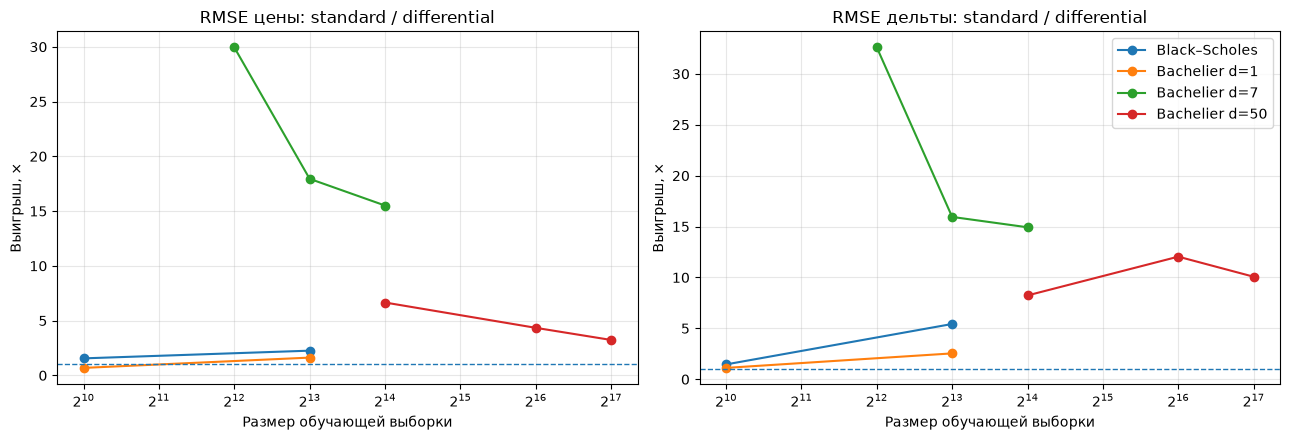

In [11]:
price = results_df.pivot(index=["task", "train_size"], columns="method", values="rmse_price")
delta = results_df.pivot(index=["task", "train_size"], columns="method", values="rmse_delta")
gain = pd.DataFrame({"price_gain_x": price["standard"] / price["differential"],
                     "delta_gain_x": delta["standard"] / delta["differential"]})
display(gain.round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for task in SIZES:
    sub = gain.loc[task]
    axes[0].plot(sub.index, sub["price_gain_x"], marker="o", label=task)
    axes[1].plot(sub.index, sub["delta_gain_x"], marker="o", label=task)
for ax, label in zip(axes, ["RMSE цены: standard / differential", "RMSE дельты: standard / differential"]):
    ax.set_xscale("log", base=2)
    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_xlabel("Размер обучающей выборки")
    ax.set_ylabel("Выигрыш, ×")
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## Примечания к воспроизводимости

- Этот ноутбук — **самостоятельная реализация на PyTorch**. Сравнение с TensorFlow и результаты CPU/GPU приведены в `README.md`; оно не требуется для запуска.
- Генерация Monte Carlo использует `np.random.default_rng`, поэтому **одинаковые seed не гарантируют побитовое совпадение** с оригинальным ноутбуком TensorFlow, использующим другой генератор.
- Инициализация сети — `xavier_uniform_` из предоставленного PyTorch-порта; это не идентичная инициализация исходного TensorFlow. Математическая корректность и результаты при общих весах проверялись отдельно.
- `full` воспроизводит выбранные размеры и параметры обучения, но не все протоколы оценки/валидации, представленные в научной статье.